In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import kagglehub

path_dir = kagglehub.dataset_download('vijaykumar1799/face-mask-detection')

Using Colab cache for faster access to the 'face-mask-detection' dataset.


In [3]:
import os
import shutil
import random

# Ratios
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

original_dataset_dir = os.path.join(path_dir,'Dataset')   # dossier téléchargé

# dossier où stocker train/val/test
base_dir = "dataset_split"
os.makedirs(base_dir, exist_ok=True)

# Crée les sous-dossiers train / val / test
for split in ["train", "val", "test"]:
    for class_name in os.listdir(original_dataset_dir):
        os.makedirs(os.path.join(base_dir, split, class_name), exist_ok=True)

# Split + copie
for class_name in os.listdir(original_dataset_dir):
    class_dir = os.path.join(original_dataset_dir, class_name)
    images = os.listdir(class_dir)
    random.shuffle(images)

    total = len(images)
    train_end = int(train_ratio * total)
    val_end = train_end + int(val_ratio * total)

    splits = {
        "train": images[:train_end],
        "val": images[train_end:val_end],
        "test": images[val_end:]
    }

    for split, files in splits.items():
        for fname in files:
            src = os.path.join(class_dir, fname)
            dst = os.path.join(base_dir, split, class_name, fname)

            # Vérifie que c'est un fichier image, pas un dossier
            if os.path.isfile(src):
                shutil.copy(src, dst)


In [4]:
train_datagen = keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2  # 20% for validation
)

test_datagen = keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

In [5]:
training_set = train_datagen.flow_from_directory(
    'dataset_split/train',
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

validation_set = train_datagen.flow_from_directory(
    'dataset_split/val',
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
    )


test_set = test_datagen.flow_from_directory(
    'dataset_split/test',
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 5028 images belonging to 3 classes.
Found 267 images belonging to 3 classes.
Found 1350 images belonging to 3 classes.


In [6]:
model = keras.Sequential([
    # 1st Convolutional Block
    keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    keras.layers.MaxPooling2D(2,2),      # Downsample with 2x2 pool size

    # 2nd Convolutional Block
    keras.layers.Conv2D(64, (3,3), activation='relu'),
    keras.layers.MaxPooling2D(2,2),

    # 3rd Convolutional Block
    keras.layers.Conv2D(128, (3,3), activation='relu'),
    keras.layers.MaxPooling2D(2,2),

    # 4th Convolutional Block
    keras.layers.Conv2D(128, (3,3), activation='relu'),
    keras.layers.MaxPooling2D(2,2),

    # Fully Connected Layers
    keras.layers.Flatten(),        # Flatten 2D features to 1D
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dropout(0.5),     # Dropout to prevent overfitting
    keras.layers.Dense(training_set.num_classes, activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
# Compile the model with optimizer, loss function, and evaluation metrics
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [8]:
# Display the model architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,421,507 (5.42 MB)

 Trainable params: 1,421,507 (5.42 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',        # Watch validation loss
    patience=5,                # Stop after 5 epochs with no improvement
    restore_best_weights=True  # Keep the best model
)


In [10]:
history = model.fit(
              training_set,
              epochs=50,
              validation_data=validation_set,
              callbacks=[early_stop]
          )

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 39s 199ms/step - accuracy: 0.6387 - loss: 0.7204 - val_accuracy: 0.9064 - val_loss: 0.2535
Epoch 2/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 27s 172ms/step - accuracy: 0.9001 - loss: 0.2811 - val_accuracy: 0.9101 - val_loss: 0.2059
Epoch 3/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 28s 176ms/step - accuracy: 0.9311 - loss: 0.2041 - val_accuracy: 0.9401 - val_loss: 0.1322
Epoch 4/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 30s 191ms/step - accuracy: 0.9471 - loss: 0.1506 - val_accuracy: 0.9588 - val_loss: 0.1182
Epoch 5/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 27s 172ms/step - accuracy: 0.9513 - loss: 0.1391 - val_accuracy: 0.9401 - val_loss: 0.1385
Epoch 6/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 31s 198ms/step - accuracy: 0.9645 - loss: 0.1107 - val_accuracy: 0.9625 - val_loss: 0.0973
Epoch 7/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 37s 174ms/step - accuracy: 0.9672 - loss: 0.0958 - val_accuracy: 0.9625 - val_loss: 0.1103
Epoch 8/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 27s 171ms/step - accuracy: 0.9721 - loss: 0

In [11]:
loss, accuracy = model.evaluate(test_set)
print(f"Test Loss: {loss}")
print(f"Test Accuracy: {accuracy * 100:.2f}%")

43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.9855 - loss: 0.0445
Test Loss: 0.06731908023357391
Test Accuracy: 98.07%


In [12]:
y_pred_prob = model.predict(test_set)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = test_set.classes

43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step


In [13]:
from sklearn.metrics import classification_report

class_labels = list(test_set.class_indices.keys())
print("Classification Report:\n", classification_report(y_true, y_pred, target_names=class_labels))

Classification Report:
                        precision    recall  f1-score   support

mask_weared_incorrect       0.97      0.99      0.98       450
            with_mask       0.98      0.97      0.97       450
         without_mask       1.00      0.98      0.99       450

             accuracy                           0.98      1350
            macro avg       0.98      0.98      0.98      1350
         weighted avg       0.98      0.98      0.98      1350



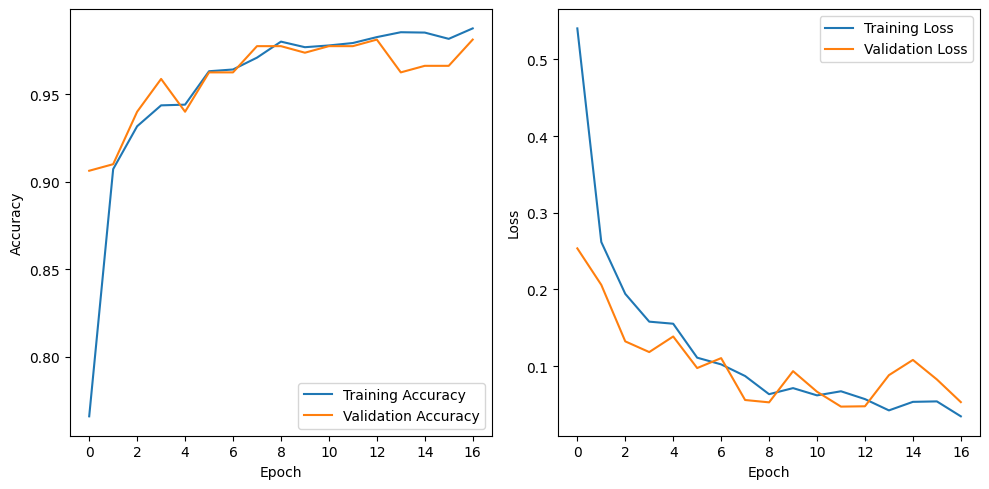

In [14]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [15]:
def predict_image(image_path, model):
    img = keras.preprocessing.image.load_img(image_path, target_size=(128, 128))
    img_array = keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.

    prediction = model.predict(img_array, verbose=0)
    predicted_class = np.argmax(prediction)

    class_labels = list(test_set.class_indices.keys())
    predicted_label = class_labels[predicted_class]

    return predicted_label


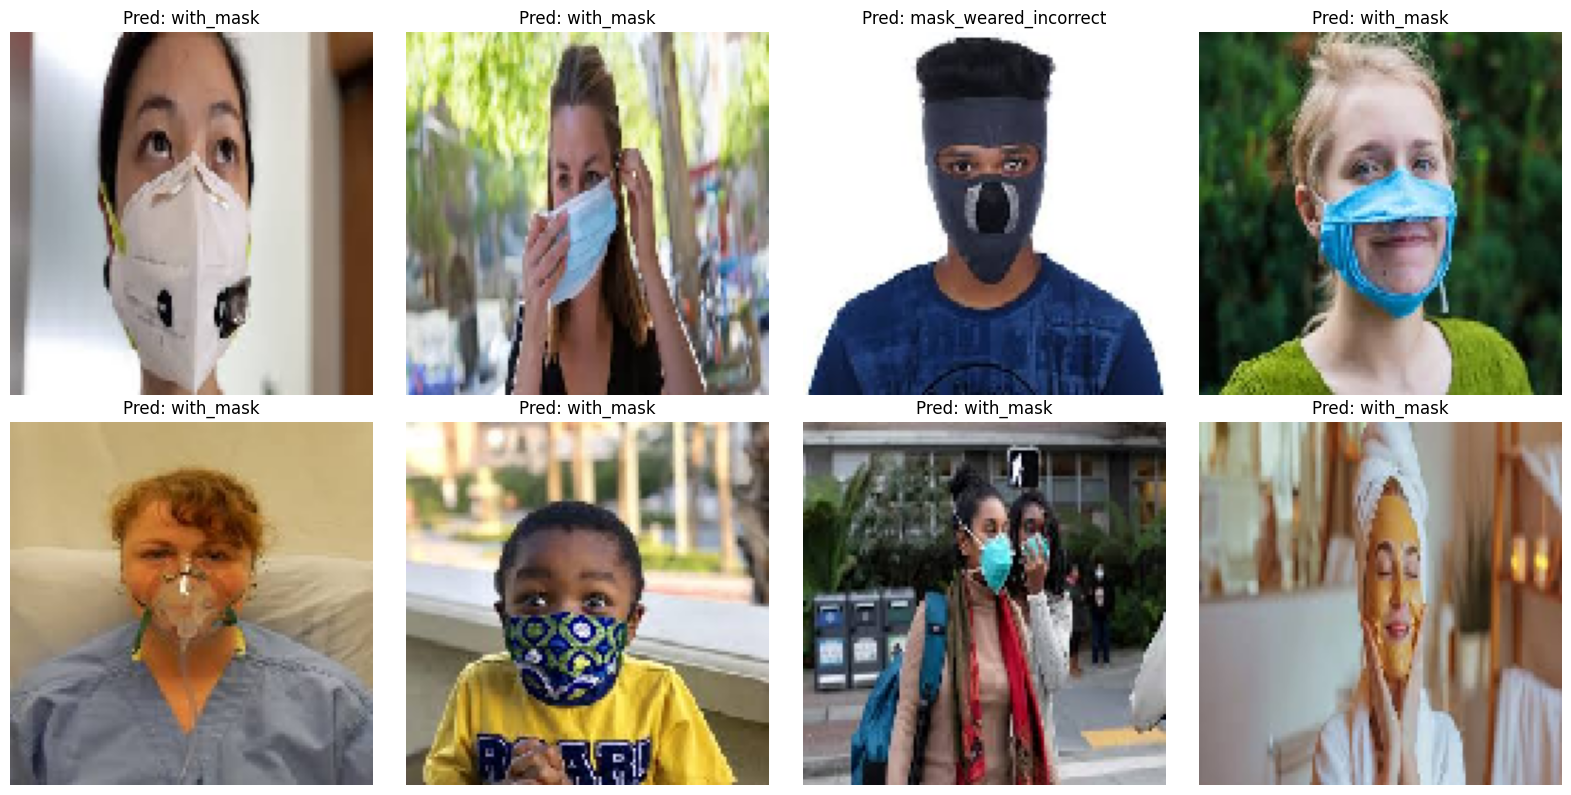

In [16]:
import math

folder_test = '/content/drive/MyDrive/Colab Notebooks/folder_test_samples'
files = os.listdir(folder_test)

n_images = len(files)

n_cols = 4
n_rows = math.ceil(n_images / n_cols)

plt.figure(figsize=(4 * n_cols, 4 * n_rows))

for i, file_name in enumerate(files):
    img_path = os.path.join(folder_test, file_name)

    predicted_label = predict_image(img_path, model)
    img = keras.preprocessing.image.load_img(img_path ,target_size=(128, 128))

    plt.subplot(n_rows, n_cols, i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Pred: {predicted_label}")

plt.tight_layout()
plt.show()


In [17]:
model.save('face_mask_detection_model.keras')